In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

possible_paths = [
    Path("observations-698663.csv/observations-698663.csv"),
    Path("observations-698663.csv"),
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Arquivo observations-698663.csv nao encontrado.")

# Deteccao automatica de delimitador
raw_df = pd.read_csv(csv_path, sep=None, engine="python")
df = raw_df.copy()

# Conversao de datas para analise temporal
for col in ["observed_on", "created_at", "updated_at", "time_observed_at"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

print(f"Arquivo usado: {csv_path}")
print(f"Shape: {df.shape}")
print("\nPrimeiras linhas:")
display(df.head())

# Perfil de colunas
col_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_abs": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(dropna=True),
}).sort_values(["missing_pct", "nunique"], ascending=[False, False])

print("\nPerfil de colunas (ordenado por missing):")
display(col_profile)

print("\nResumo numerico (colunas com >= 5% valores validos):")
num_cols = df.select_dtypes(include=[np.number]).columns
num_keep = [c for c in num_cols if df[c].notna().mean() >= 0.05]
if num_keep:
    display(df[num_keep].describe().T)
else:
    print("Sem colunas numericas com dados suficientes.")

print("\nResumo categorico (top 25):")
display(df.describe(include=["object", "string"]).T.head(25))

Arquivo usado: observations-698663.csv/observations-698663.csv
Shape: (57023, 68)

Primeiras linhas:


,id,uuid,observed_on_string,observed_on,time_observed_at,time_zone,user_id,user_login,user_name,created_at,...,taxon_supertribe_name,taxon_tribe_name,taxon_subtribe_name,taxon_genus_name,taxon_genushybrid_name,taxon_species_name,taxon_hybrid_name,taxon_subspecies_name,taxon_variety_name,taxon_form_name
0,478790,24299842-b733-4d85-9a48-32fa7433c6ab,2013-12-07,2013-12-07 00:00:00+00:00,NaT,Lisbon,3042,duarte,Duarte Frade,2013-12-09 18:45:17+00:00,...,NaN,NaN,NaN,Schizophyllum,NaN,Schizophyllum commune,NaN,NaN,NaN,NaN
1,478794,51322a02-f7b0-445b-97d7-a26c0fe9713d,"December 3, 2013",2013-12-03 00:00:00+00:00,NaT,Lisbon,3042,duarte,Duarte Frade,2013-12-09 18:55:11+00:00,...,NaN,NaN,NaN,Armillaria,NaN,NaN,NaN,NaN,NaN,NaN
2,495433,cceff5c4-3a8e-45e1-9ca1-f547de24b0b1,2014-01-03,2014-01-03 00:00:00+00:00,NaT,Lisbon,3042,duarte,Duarte Frade,2014-01-06 21:58:02+00:00,...,NaN,NaN,NaN,Trametes,NaN,Trametes versicolor,NaN,NaN,NaN,NaN
3,547921,fc02f08c-465f-48b4-9949-e3be8afafba2,2014-02-10,2014-02-10 00:00:00+00:00,NaT,Mexico City,27305,nicolas_moreno_v,Nicolás Moreno V.,2014-03-02 00:22:44+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,582299,06e365c0-eea7-4b2f-ab09-904032dd137f,2014-03-15,2014-03-15 00:00:00+00:00,NaT,Madrid,2608,xbejard,Xavier Béjar,2014-03-25 13:51:06+00:00,...,NaN,NaN,NaN,Cynomorium,NaN,Cynomorium coccineum,NaN,NaN,NaN,NaN



Perfil de colunas (ordenado por missing):


,dtype,missing_abs,missing_pct,nunique
taxon_subtribe_name,str,57021,100.0,2
taxon_subspecies_name,str,57022,100.0,1
sound_url,float64,57023,100.0,0
private_place_guess,float64,57023,100.0,0
private_latitude,float64,57023,100.0,0
...,...,...,...,...
taxon_kingdom_name,str,2,0.0,4
num_identification_disagreements,int64,0,0.0,3
quality_grade,str,0,0.0,2
coordinates_obscured,bool,0,0.0,2



Resumo numerico (colunas com >= 5% valores validos):


,count,mean,std,min,25%,50%,75%,max
id,57023.0,1.910390e+08,9.561490e+07,478790.000000,1.042283e+08,1.914019e+08,2.583202e+08,3.447833e+08
user_id,57023.0,4.248053e+06,2.670532e+06,67.000000,1.978464e+06,3.966778e+06,6.229322e+06,1.027911e+07
num_identification_agreements,57023.0,8.400470e-01,9.235829e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
num_identification_disagreements,57023.0,2.088631e-02,1.436169e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
oauth_application_id,39758.0,3.145297e+01,1.431760e+02,2.000000,2.000000e+00,2.000000e+00,3.000000e+00,8.430000e+02
latitude,57023.0,4.055528e+01,1.799123e+00,36.013267,3.905437e+01,4.064512e+01,4.205580e+01,4.377290e+01
longitude,57023.0,-5.285639e+00,3.665341e+00,-9.566242,-8.530658e+00,-6.196647e+00,-3.161039e+00,3.360022e+00
positional_accuracy,40887.0,1.218067e+03,8.626443e+03,0.000000,7.000000e+00,2.500000e+01,2.190000e+02,3.164850e+05
public_positional_accuracy,41666.0,3.141305e+03,1.094138e+04,0.000000,8.000000e+00,3.200000e+01,4.117500e+02,3.164850e+05
taxon_id,57022.0,9.663082e+04,1.373625e+05,27726.000000,4.716900e+04,4.954800e+04,5.595000e+04,1.621448e+06



Resumo categorico (top 25):


,count,unique,top,freq
uuid,57023,57023,24299842-b733-4d85-9a48-32fa7433c6ab,1
observed_on_string,57023,55430,2011-12-07,15
time_zone,57023,46,Madrid,27043
user_login,57023,10459,maremimar,830
user_name,41975,6612,Maria Emília Martins,830
quality_grade,57023,2,needs_id,41907
license,41174,7,CC-BY-NC,34629
url,57023,57023,http://www.inaturalist.org/observations/478790,1
image_url,57023,57020,https://inaturalist-open-data.s3.amazonaws.com...,2
tag_list,1327,495,"Junipero oxycedry-Quercetum rotundifoliae, IV3...",273


Top 20 colunas com mais valores ausentes:


,missing_abs,missing_pct
private_place_guess,57023,100.00
private_latitude,57023,100.00
private_longitude,57023,100.00
sound_url,57023,100.00
taxon_supertribe_name,57023,100.00
taxon_genushybrid_name,57023,100.00
taxon_form_name,57023,100.00
taxon_superclass_name,57023,100.00
taxon_hybrid_name,57023,100.00
taxon_variety_name,57023,100.00



Linhas duplicadas: 0 (0.00%)

Distribuicao de quality_grade:


,count,pct
quality_grade,,
needs_id,41907,73.49
research,15116,26.51


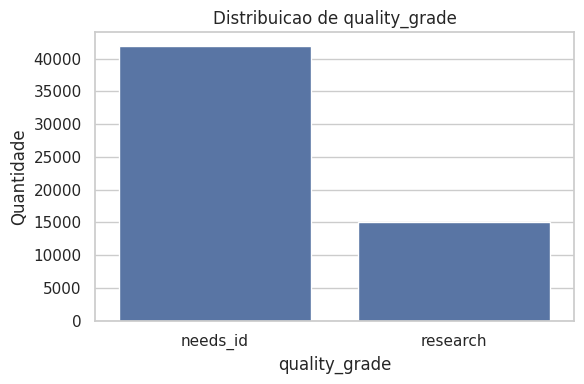


Top 15 especies (scientific_name binomial):


,count
scientific_name,
Volvopluteus gloiocephalus,2985
Schizophyllum commune,2526
Trametes versicolor,2060
Laetiporus sulphureus,1395
Lactarius deliciosus,1299
Armillaria mellea,1137
Phallus impudicus,1127
Marasmius oreades,1108
Omphalotus olearius,893


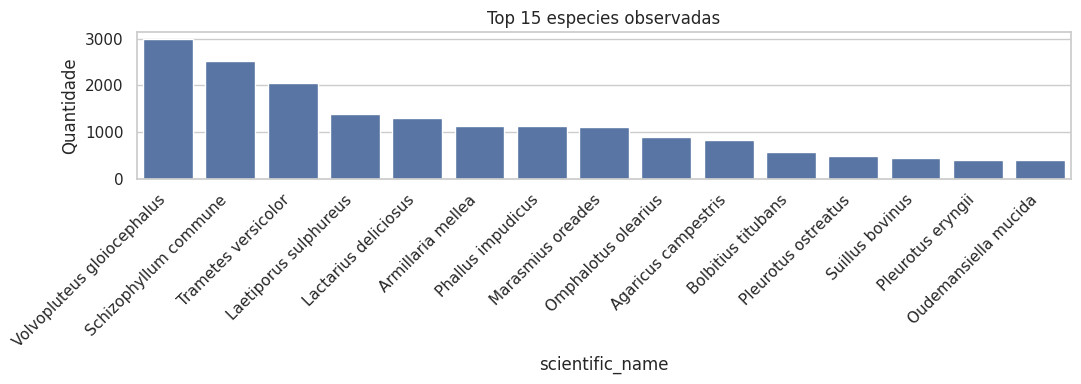

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Qualidade dos dados
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_abs / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_abs": missing_abs, "missing_pct": missing_pct})

print("Top 20 colunas com mais valores ausentes:")
display(missing_table.head(20))

n_duplicates = df.duplicated().sum()
print(f"\nLinhas duplicadas: {n_duplicates} ({n_duplicates/len(df)*100:.2f}%)")

# Distribuicao de quality_grade
if "quality_grade" in df.columns:
    q = df["quality_grade"].value_counts(dropna=False)
    qp = (df["quality_grade"].value_counts(normalize=True, dropna=False) * 100).round(2)
    print("\nDistribuicao de quality_grade:")
    display(pd.DataFrame({"count": q, "pct": qp}))

    plt.figure(figsize=(6, 4))
    sns.barplot(x=q.index.astype(str), y=q.values)
    plt.title("Distribuicao de quality_grade")
    plt.xlabel("quality_grade")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()

# Top especies binomiais
if "scientific_name" in df.columns:
    species = df["scientific_name"].dropna().astype(str)
    species = species[species.str.contains(" ")]
    top_species = species.value_counts().head(15)

    print("\nTop 15 especies (scientific_name binomial):")
    display(top_species.to_frame("count"))

    plt.figure(figsize=(11, 4))
    sns.barplot(x=top_species.index, y=top_species.values)
    plt.title("Top 15 especies observadas")
    plt.xlabel("scientific_name")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Observacoes com coordenadas: 57023 / 57023 (100.00%)

Top 12 estados/distritos:


,count
place_state_name,
Comunidad de Madrid,7126
Cataluña,4963
Lisboa,4583
Galicia,4074
Andalucía,3674
Castilla y León,2576
Porto,2400
Setúbal,2248
Coimbra,2195


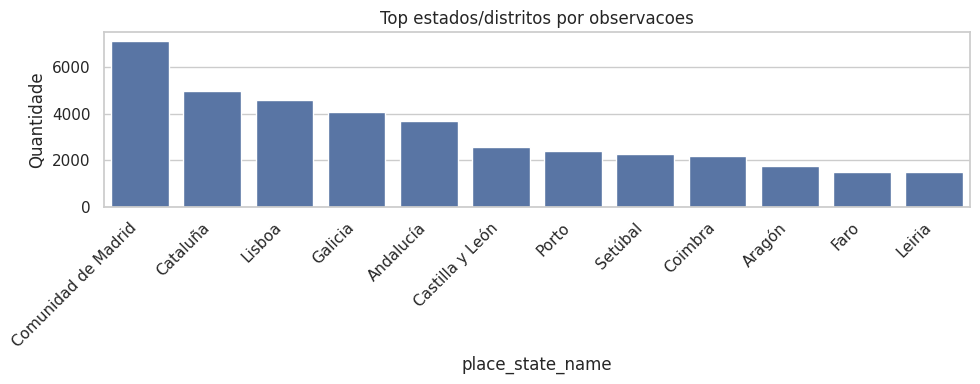


Top 12 concelhos:


,count
place_county_name,
Madrid,7126
Barcelona,2560
Lisboa,2273
A Coruña,1639
Girona,1482
Navarra,1416
Pontevedra,1249
Coimbra,1124
Huesca,970


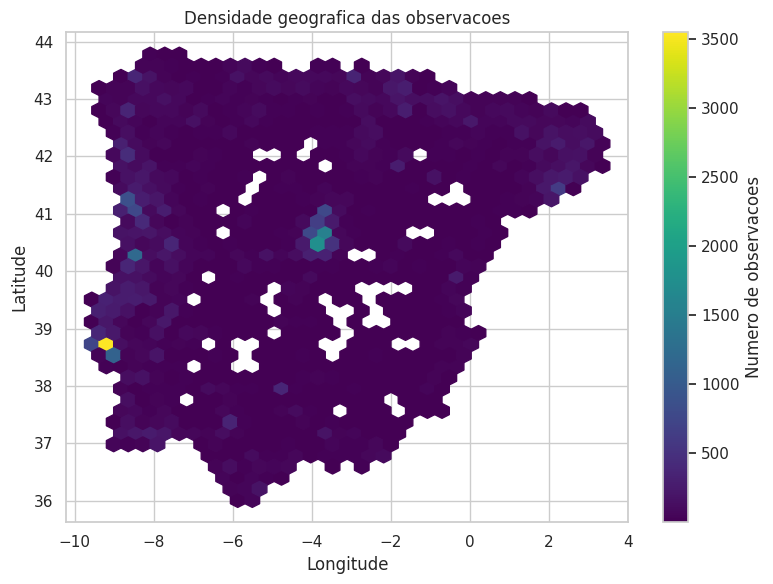

In [11]:
# Analise geografica
if {"latitude", "longitude"}.issubset(df.columns):
    geo_df = df.dropna(subset=["latitude", "longitude"]).copy()
    print(f"Observacoes com coordenadas: {len(geo_df)} / {len(df)} ({len(geo_df)/len(df)*100:.2f}%)")

    if "place_state_name" in geo_df.columns:
        top_states = geo_df["place_state_name"].fillna("(desconhecido)").value_counts().head(12)
        print("\nTop 12 estados/distritos:")
        display(top_states.to_frame("count"))

        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_states.index, y=top_states.values)
        plt.title("Top estados/distritos por observacoes")
        plt.xlabel("place_state_name")
        plt.ylabel("Quantidade")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    if "place_county_name" in geo_df.columns:
        top_counties = geo_df["place_county_name"].fillna("(desconhecido)").value_counts().head(12)
        print("\nTop 12 concelhos:")
        display(top_counties.to_frame("count"))

    plt.figure(figsize=(8, 6))
    plt.hexbin(geo_df["longitude"], geo_df["latitude"], gridsize=35, cmap="viridis", mincnt=1)
    plt.colorbar(label="Numero de observacoes")
    plt.title("Densidade geografica das observacoes")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("Colunas de latitude/longitude nao disponiveis para analise geografica.")

Observacoes por mes:


,count
month,
1,3581
2,2346
3,2326
4,2039
5,1928
6,1419
7,1140
8,1573
9,3618


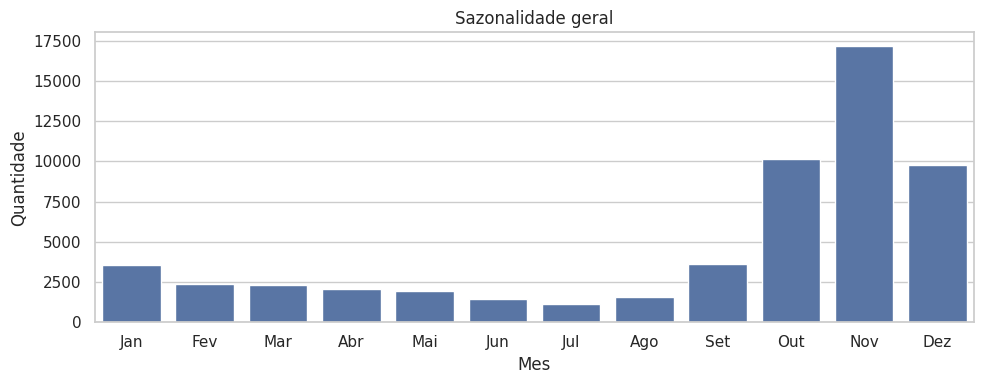


Heatmap mensal das top 8 especies:


month,1,2,3,4,5,6,7,8,9,10,11,12
scientific_name,,,,,,,,,,,,
Armillaria mellea,16,6,0,3,2,14,4,4,10,397,437,244
Lactarius deliciosus,62,7,5,1,0,3,9,11,78,284,491,348
Laetiporus sulphureus,8,3,4,15,62,36,44,341,497,278,87,20
Marasmius oreades,26,19,28,58,83,54,11,11,93,237,397,91
Phallus impudicus,105,15,4,7,20,50,101,62,27,115,325,296
Schizophyllum commune,382,370,339,221,150,80,53,67,71,149,315,329
Trametes versicolor,227,203,179,151,97,59,68,66,124,223,359,304
Volvopluteus gloiocephalus,222,54,30,13,14,8,3,7,13,169,1374,1078


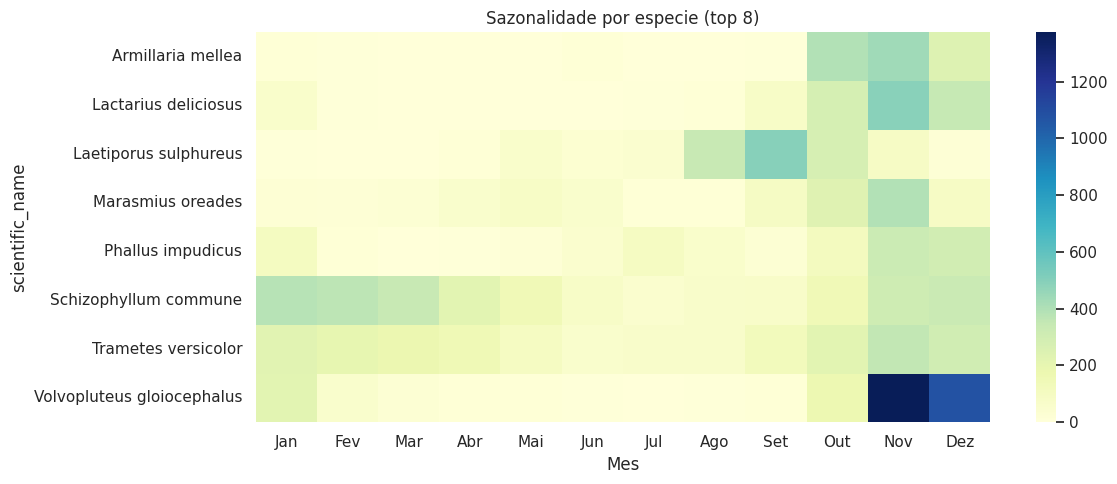

In [12]:
# Sazonalidade
if "observed_on" in df.columns:
    season_df = df.dropna(subset=["observed_on"]).copy()
    season_df["month"] = season_df["observed_on"].dt.month

    monthly_counts = season_df["month"].value_counts().sort_index()
    month_labels = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

    print("Observacoes por mes:")
    display(monthly_counts.to_frame("count"))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=[month_labels[m - 1] for m in monthly_counts.index], y=monthly_counts.values)
    plt.title("Sazonalidade geral")
    plt.xlabel("Mes")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()

    if "scientific_name" in season_df.columns:
        species = season_df["scientific_name"].dropna().astype(str)
        species = species[species.str.contains(" ")]
        top_species8 = species.value_counts().head(8).index.tolist()

        sp_month = (
            season_df[season_df["scientific_name"].isin(top_species8)]
            .groupby(["scientific_name", "month"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=range(1, 13), fill_value=0)
        )

        print("\nHeatmap mensal das top 8 especies:")
        display(sp_month)

        plt.figure(figsize=(12, 5))
        sns.heatmap(sp_month, cmap="YlGnBu")
        plt.title("Sazonalidade por especie (top 8)")
        plt.xlabel("Mes")
        plt.ylabel("scientific_name")
        plt.xticks(ticks=np.arange(12) + 0.5, labels=month_labels, rotation=0)
        plt.tight_layout()
        plt.show()
else:
    print("Coluna observed_on nao disponivel para analise de sazonalidade.")

Top 10 paises por observacoes e distribuicao de quality_grade:


quality_grade,needs_id,research
place_country_name,,
(desconhecido),5,1
Andorra,55,6
France,1177,447
Gibraltar,32,12
Portugal,17009,6178
Spain,23629,8472


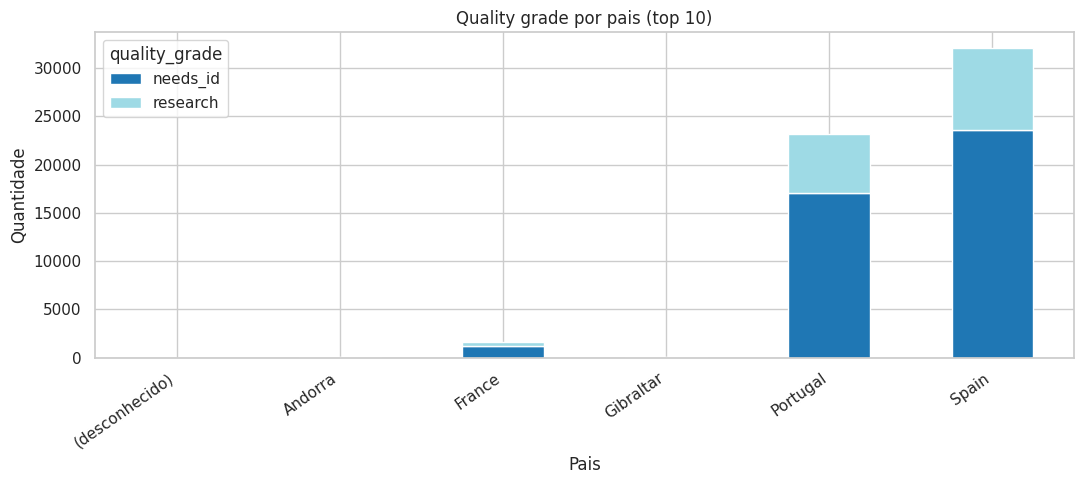


Percentual de observacoes 'research' por pais:


,research_pct
place_country_name,
France,27.524631
Gibraltar,27.272727
Portugal,26.644240
Spain,26.391701
(desconhecido),16.666667
Andorra,9.836066


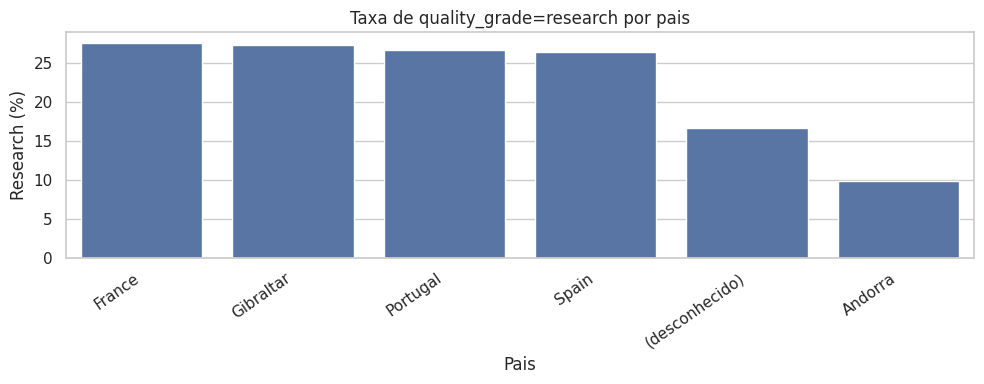

In [13]:
# Comparativo por pais e quality_grade
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if {"place_country_name", "quality_grade"}.issubset(df.columns):
    country_df = df.copy()
    country_df["place_country_name"] = country_df["place_country_name"].fillna("(desconhecido)")

    top_countries = country_df["place_country_name"].value_counts().head(10).index
    ctab = pd.crosstab(
        country_df[country_df["place_country_name"].isin(top_countries)]["place_country_name"],
        country_df[country_df["place_country_name"].isin(top_countries)]["quality_grade"],
    )

    print("Top 10 paises por observacoes e distribuicao de quality_grade:")
    display(ctab)

    ctab.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
    plt.title("Quality grade por pais (top 10)")
    plt.xlabel("Pais")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

    if "research" in ctab.columns:
        research_rate = (ctab["research"] / ctab.sum(axis=1) * 100).sort_values(ascending=False)
        print("\nPercentual de observacoes 'research' por pais:")
        display(research_rate.to_frame("research_pct"))

        plt.figure(figsize=(10, 4))
        sns.barplot(x=research_rate.index, y=research_rate.values)
        plt.title("Taxa de quality_grade=research por pais")
        plt.xlabel("Pais")
        plt.ylabel("Research (%)")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("Colunas place_country_name e/ou quality_grade nao disponiveis.")

Serie mensal por pais (top 4):


,year_month,country,count
0,1981-03-01,Spain,1
1,1981-04-01,Spain,1
2,1982-01-01,Spain,2
3,1983-07-01,Spain,3
4,1983-08-01,Spain,1
5,1983-10-01,Spain,2
6,1984-12-01,Spain,1
7,1986-10-01,Spain,1
8,1987-11-01,Spain,1
9,1992-04-01,Spain,1


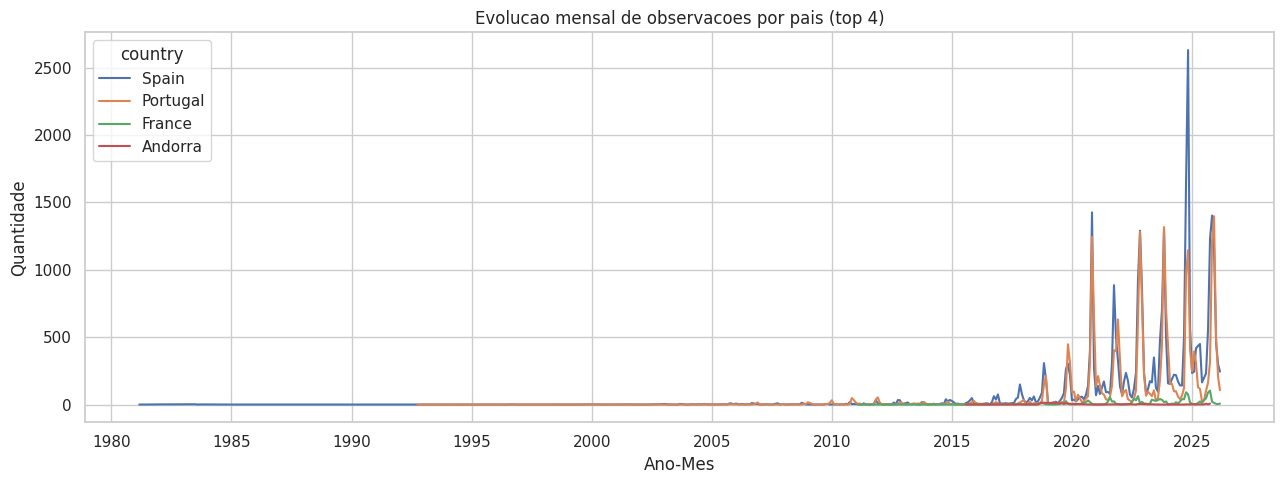

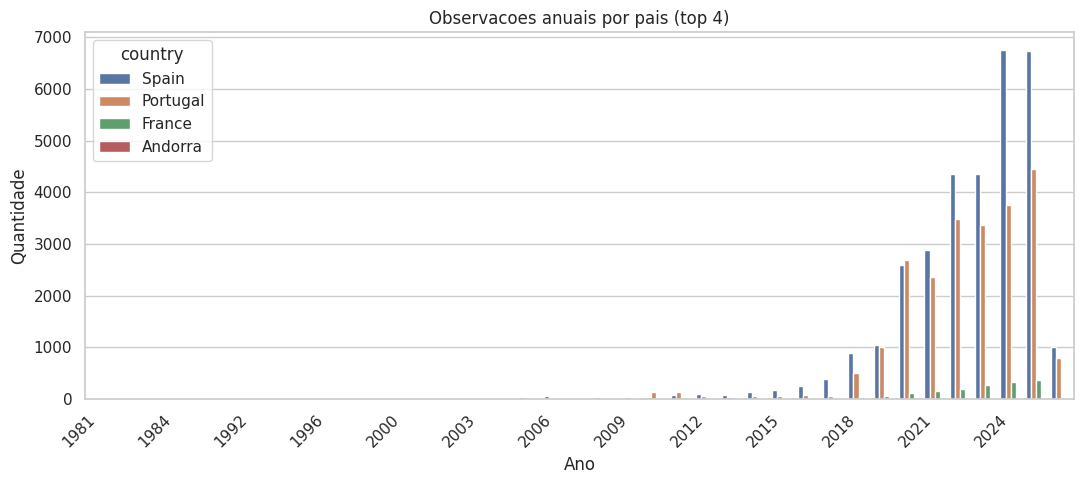

In [14]:
# Evolucao temporal por pais (top 4)
if {"observed_on", "place_country_name"}.issubset(df.columns):
    ts_df = df.dropna(subset=["observed_on"]).copy()
    ts_df["country"] = ts_df["place_country_name"].fillna("(desconhecido)")

    # Remove timezone antes de converter para mes para evitar warning e facilitar o plot
    ts_df["year_month"] = (
        ts_df["observed_on"]
        .dt.tz_localize(None)
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    top4 = ts_df["country"].value_counts().head(4).index.tolist()
    ts_top = ts_df[ts_df["country"].isin(top4)]

    monthly_country = (
        ts_top.groupby(["year_month", "country"])
        .size()
        .reset_index(name="count")
    )

    print("Serie mensal por pais (top 4):")
    display(monthly_country.head(20))

    plt.figure(figsize=(13, 5))
    sns.lineplot(data=monthly_country, x="year_month", y="count", hue="country")
    plt.title("Evolucao mensal de observacoes por pais (top 4)")
    plt.xlabel("Ano-Mes")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()

    # Agregado anual para reduzir ruido e facilitar comparacao
    ts_df["year"] = ts_df["observed_on"].dt.year
    yearly_country = (
        ts_df[ts_df["country"].isin(top4)]
        .groupby(["year", "country"])
        .size()
        .reset_index(name="count")
    )

    years_order = sorted(yearly_country["year"].dropna().unique().tolist())
    step = 1 if len(years_order) <= 15 else 2 if len(years_order) <= 30 else 3

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(data=yearly_country, x="year", y="count", hue="country", order=years_order)
    plt.title("Observacoes anuais por pais (top 4)")
    plt.xlabel("Ano")
    plt.ylabel("Quantidade")

    tick_pos = list(range(0, len(years_order), step))
    tick_lbl = [str(years_order[i]) for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("Colunas observed_on e/ou place_country_name nao disponiveis.")

Top 12 estados/distritos: observacoes e diversidade de especies:


,observacoes,especies_unicas
state,,
Comunidad de Madrid,7126,70
Cataluña,4963,95
Lisboa,4583,114
Galicia,4074,85
Andalucía,3674,66
Castilla y León,2576,75
Porto,2400,67
Setúbal,2248,62
Coimbra,2195,112


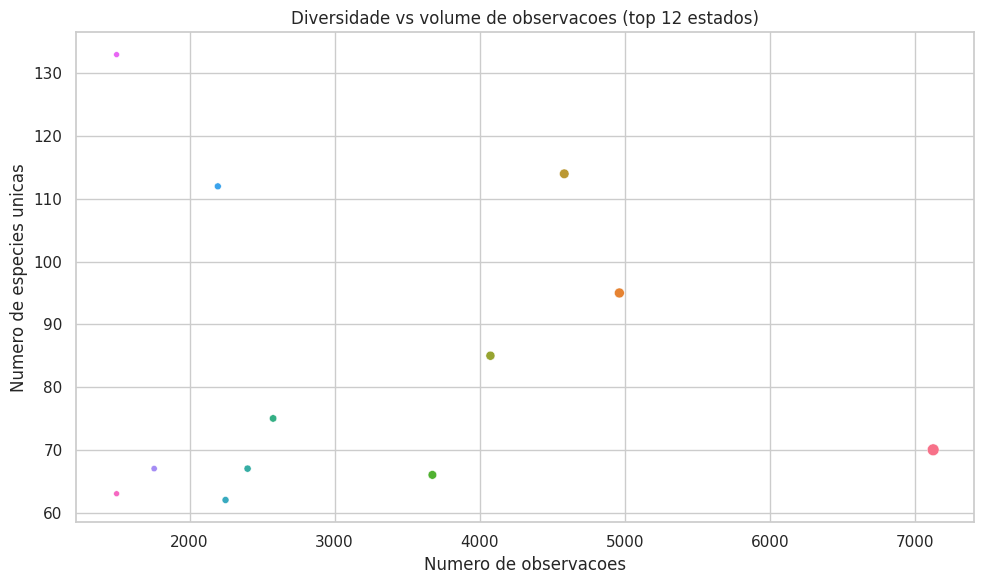


Top 15 utilizadores por numero de observacoes:


,count
user_login,
maremimar,830
angel_fernandez_cancio,752
amanithor,749
jonatan_antunez,528
deinonyco,439
rodrimarquez,384
jonnyvanbatman,383
luisballester,335
brandao,296


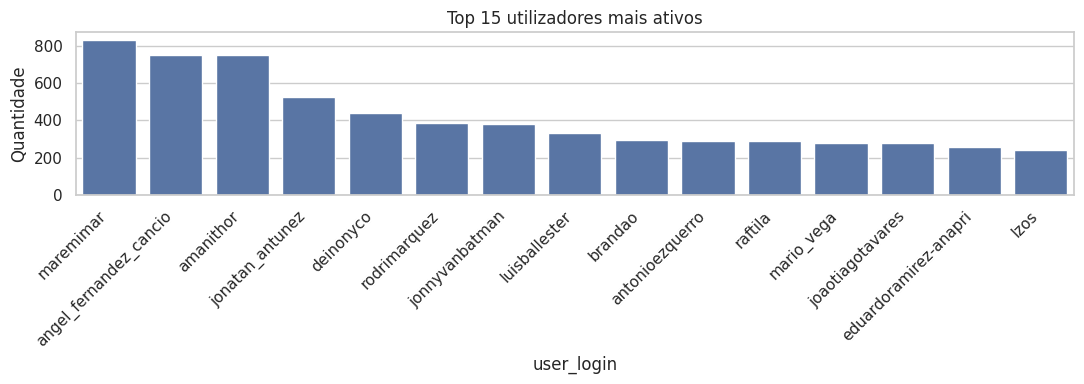

In [15]:
# Diversidade por estado/distrito e top observadores
if {"place_state_name", "scientific_name"}.issubset(df.columns):
    div_df = df.copy()
    div_df["state"] = div_df["place_state_name"].fillna("(desconhecido)")
    div_df["scientific_name"] = div_df["scientific_name"].fillna("(nao identificado)")

    state_stats = (
        div_df.groupby("state")
        .agg(
            observacoes=("id", "count"),
            especies_unicas=("scientific_name", "nunique")
        )
        .sort_values("observacoes", ascending=False)
    )

    top12_states = state_stats.head(12)
    print("Top 12 estados/distritos: observacoes e diversidade de especies:")
    display(top12_states)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=top12_states.reset_index(),
        x="observacoes", y="especies_unicas", size="observacoes", hue="state", legend=False
    )
    plt.title("Diversidade vs volume de observacoes (top 12 estados)")
    plt.xlabel("Numero de observacoes")
    plt.ylabel("Numero de especies unicas")
    plt.tight_layout()
    plt.show()

if "user_login" in df.columns:
    top_users = df["user_login"].fillna("(desconhecido)").value_counts().head(15)
    print("\nTop 15 utilizadores por numero de observacoes:")
    display(top_users.to_frame("count"))

    plt.figure(figsize=(11, 4))
    sns.barplot(x=top_users.index, y=top_users.values)
    plt.title("Top 15 utilizadores mais ativos")
    plt.xlabel("user_login")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Preparacao para Tableau (DW + Data Marts)

A partir desta secao, o notebook cria um modelo estrela e tabelas agregadas para dashboards no Tableau.

Saidas geradas em `tableau_exports/`:
- `dim_species.csv`
- `dim_location.csv`
- `dim_time.csv`
- `fact_mushroom_observation.csv`
- `mart_country_year_quality.csv`
- `mart_species_season_region.csv`
- `mart_state_risk_diversity.csv`

In [19]:
# Lista todas as especies no dataset
if "scientific_name" in df.columns:
    all_species = df["scientific_name"].dropna().unique()
    for sp in sorted(all_species):
        print(f"{sp}")
else:
    print("Coluna scientific_name nao disponivel para listar especies.")

Abortiporus biennis
Acari
Agaricaceae
Agaricales
Agaricineae
Agaricomycetes
Agaricus
Agaricus arvensis
Agaricus augustus
Agaricus bisporus
Agaricus bitorquis
Agaricus bohusii
Agaricus brunneolus
Agaricus campestris
Agaricus comtulus
Agaricus crocodilinus
Agaricus cupreobrunneus
Agaricus dulcidulus
Agaricus impudicus
Agaricus incultorum
Agaricus langei
Agaricus litoralis
Agaricus matrum
Agaricus moelleri
Agaricus moelleroides
Agaricus placomyces
Agaricus pseudopratensis
Agaricus subrufescens
Agaricus sylvaticus
Agaricus sylvicola
Agaricus xanthodermus
Aleocharinae
Aleuria aurantia
Amanita
Amanita caesarea
Amanita citrina
Amanita curtipes
Amanita gioiosa
Amanita muscaria
Amanita ponderosa
Amanita rubescens
Amanita verna
Amanitaceae
Anacamptis papilionacea
Anoplotrupes
Aphididae
Arion
Arion ater
Arion fuligineus
Arion vulgaris
Armillaria
Armillaria mellea
Armillaria novae-zelandiae
Armillaria ostoyae
Arrhenia
Asterophora parasitica
Astraeus hygrometricus
Atheta
Auricularia mesenterica
Aur

In [22]:
from pathlib import Path

# =============================
# 1) Feature engineering base
# =============================
dw = df.copy().reset_index(drop=True)

# obs_id robusto (usa id quando existe, senao indice + 1)
dw["obs_id"] = dw.get("id", pd.Series(index=dw.index, dtype="float64"))
missing_obs_id = dw["obs_id"].isna()
dw.loc[missing_obs_id, "obs_id"] = (dw.index[missing_obs_id] + 1).astype(float)
dw["obs_id"] = dw["obs_id"].astype("int64")

# Datas e componentes temporais
dw["observation_date"] = pd.to_datetime(dw.get("observed_on"), errors="coerce", utc=True).dt.tz_localize(None)
dw["year"] = dw["observation_date"].dt.year
dw["month"] = dw["observation_date"].dt.month
dw["week"] = dw["observation_date"].dt.isocalendar().week.astype("Int64")
dw["day_of_week"] = dw["observation_date"].dt.day_name().fillna("Unknown")

def month_to_season(m):
    if pd.isna(m):
        return "unknown"
    m = int(m)
    if m in (12, 1, 2):
        return "winter"
    if m in (3, 4, 5):
        return "spring"
    if m in (6, 7, 8):
        return "summer"
    return "autumn"

dw["season"] = dw["month"].apply(month_to_season)

# Regiao norte/sul (proxy simples para Iberia)
dw["region_pt"] = np.where(dw.get("latitude", pd.Series([np.nan] * len(dw))).fillna(0) >= 40.5, "norte", "sul")

# Habitat proxy a partir de metadados disponiveis
if "place_county_name" in dw.columns:
    dw["habitat_type"] = dw["place_county_name"].fillna("unknown")
else:
    dw["habitat_type"] = "unknown"

# Metrica de media por observacao
dw["media_count"] = 0
dw["media_count"] += dw.get("image_url", pd.Series(index=dw.index)).notna().astype(int)
dw["media_count"] += dw.get("sound_url", pd.Series(index=dw.index)).notna().astype(int)
dw["observation_count"] = 1

# Edibilidade: mapeamento parcial (resto = desconhecido)
toxic_species = {
    "Amanita phalloides", "Amanita muscaria", "Amanita pantherina", "Omphalotus olearius"
}
edible_species = {
    "Pleurotus ostreatus", "Pleurotus eryngii", "Boletus edulis", "Lactarius deliciosus", "Agaricus campestris"
}

dw["scientific_name"] = dw.get("scientific_name", pd.Series([np.nan] * len(dw))).astype("string")
sci = dw["scientific_name"].fillna("")
dw["edibility_status"] = np.where(sci.isin(toxic_species), "poisonous", np.where(sci.isin(edible_species), "edible", "unknown"))
dw["edible"] = np.where(dw["edibility_status"] == "edible", 1, np.where(dw["edibility_status"] == "poisonous", 0, np.nan))
dw["toxicity_level"] = np.where(dw["edibility_status"] == "poisonous", "high", np.where(dw["edibility_status"] == "edible", "low", "unknown"))

# =============================
# 2) Dimensoes
# =============================
for c in ["common_name", "taxon_family_name", "latitude", "longitude", "place_country_name", "place_state_name", "place_county_name"]:
    if c not in dw.columns:
        dw[c] = np.nan

dim_species = (
    dw[["scientific_name", "common_name", "taxon_family_name", "edibility_status", "toxicity_level"]]
    .rename(columns={"taxon_family_name": "family"})
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_species.insert(0, "species_id", np.arange(1, len(dim_species) + 1))

dim_location = (
    dw[["latitude", "longitude", "region_pt", "habitat_type", "place_country_name", "place_state_name", "place_county_name"]]
    .rename(columns={"place_country_name": "country", "place_state_name": "state", "place_county_name": "county"})
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_location.insert(0, "location_id", np.arange(1, len(dim_location) + 1))

dim_time = (
    dw[["observation_date", "year", "month", "season", "week", "day_of_week"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_time.insert(0, "time_id", np.arange(1, len(dim_time) + 1))

# =============================
# 3) Fato (via merge robusto)
# =============================
fact = dw.merge(
    dim_species,
    left_on=["scientific_name", "common_name", "taxon_family_name", "edibility_status", "toxicity_level"],
    right_on=["scientific_name", "common_name", "family", "edibility_status", "toxicity_level"],
    how="left",
)

fact = fact.rename(columns={"place_country_name": "country", "place_state_name": "state", "place_county_name": "county"})
fact = fact.merge(
    dim_location,
    on=["latitude", "longitude", "region_pt", "habitat_type", "country", "state", "county"],
    how="left",
)

fact = fact.merge(
    dim_time,
    on=["observation_date", "year", "month", "season", "week", "day_of_week"],
    how="left",
)

fact_mushroom_observation = fact[[
    "obs_id", "species_id", "location_id", "time_id", "edible", "observation_count", "media_count"
]].copy()

# =============================
# 4) Export CSVs para Tableau
# =============================
out_dir = Path("tableau_exports")
out_dir.mkdir(parents=True, exist_ok=True)

dim_species.to_csv(out_dir / "dim_species.csv", index=False)
dim_location.to_csv(out_dir / "dim_location.csv", index=False)
dim_time.to_csv(out_dir / "dim_time.csv", index=False)
fact_mushroom_observation.to_csv(out_dir / "fact_mushroom_observation.csv", index=False)

print("Arquivos DW exportados em:", out_dir)
print("dim_species:", dim_species.shape)
print("dim_location:", dim_location.shape)
print("dim_time:", dim_time.shape)
print("fact_mushroom_observation:", fact_mushroom_observation.shape)

Arquivos DW exportados em: tableau_exports
dim_species: (403, 6)
dim_location: (52893, 8)
dim_time: (3862, 7)
fact_mushroom_observation: (57023, 7)


In [23]:
# Data marts para dashboards no Tableau
from pathlib import Path

out_dir = Path("tableau_exports")
out_dir.mkdir(parents=True, exist_ok=True)

# Garante base DW minima, caso a celula anterior nao tenha sido executada
if "dw" not in globals():
    dw = df.copy()
    dw["observation_date"] = pd.to_datetime(dw.get("observed_on"), errors="coerce", utc=True).dt.tz_localize(None)
    dw["month"] = dw["observation_date"].dt.month
    dw["season"] = dw["month"].map({12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring", 6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"}).fillna("unknown")
    dw["region_pt"] = np.where(dw.get("latitude", pd.Series([np.nan] * len(dw))).fillna(0) >= 40.5, "norte", "sul")
    dw["obs_id"] = dw.get("id", pd.Series(index=dw.index)).fillna(pd.Series(dw.index + 1, index=dw.index)).astype("int64")
    if "edible" not in dw.columns:
        dw["edible"] = np.nan

# 1) Pais x Ano x Quality
mart_country_year_quality = (
    df.assign(
        observed_on=pd.to_datetime(df["observed_on"], errors="coerce", utc=True).dt.tz_localize(None),
        country=df["place_country_name"].fillna("(desconhecido)") if "place_country_name" in df.columns else "(desconhecido)",
        quality_grade=df["quality_grade"].fillna("unknown") if "quality_grade" in df.columns else "unknown"
    )
    .assign(year=lambda x: x["observed_on"].dt.year)
    .groupby(["country", "year", "quality_grade"], dropna=False)
    .size()
    .reset_index(name="observation_count")
)

# 2) Especie x Estacao x Regiao
mart_species_season_region = (
    dw.assign(species_name=dw.get("scientific_name", pd.Series(["(unknown)"] * len(dw))).fillna("(unknown)"))
    .groupby(["species_name", "season", "region_pt"], dropna=False)
    .size()
    .reset_index(name="observation_count")
)

# 3) Estado x risco x diversidade
state_div = (
    dw.assign(
        state=dw.get("place_state_name", pd.Series(["(desconhecido)"] * len(dw))).fillna("(desconhecido)"),
        species_name=dw.get("scientific_name", pd.Series(["(unknown)"] * len(dw))).fillna("(unknown)")
    )
    .groupby("state", dropna=False)
    .agg(
        observations=("obs_id", "count"),
        species_diversity=("species_name", "nunique"),
        known_edible_ratio=("edible", "mean")
    )
    .reset_index()
)
mart_state_risk_diversity = state_div

mart_country_year_quality.to_csv(out_dir / "mart_country_year_quality.csv", index=False)
mart_species_season_region.to_csv(out_dir / "mart_species_season_region.csv", index=False)
mart_state_risk_diversity.to_csv(out_dir / "mart_state_risk_diversity.csv", index=False)

print("Data marts exportados:")
print("-", out_dir / "mart_country_year_quality.csv", mart_country_year_quality.shape)
print("-", out_dir / "mart_species_season_region.csv", mart_species_season_region.shape)
print("-", out_dir / "mart_state_risk_diversity.csv", mart_state_risk_diversity.shape)

display(mart_country_year_quality.head(10))
display(mart_species_season_region.head(10))
display(mart_state_risk_diversity.head(10))

Data marts exportados:
- tableau_exports/mart_country_year_quality.csv (177, 4)
- tableau_exports/mart_species_season_region.csv (900, 4)
- tableau_exports/mart_state_risk_diversity.csv (46, 4)


,country,year,quality_grade,observation_count
0,(desconhecido),2022,needs_id,1
1,(desconhecido),2024,needs_id,2
2,(desconhecido),2025,needs_id,2
3,(desconhecido),2025,research,1
4,Andorra,2015,research,1
5,Andorra,2016,needs_id,2
6,Andorra,2018,needs_id,19
7,Andorra,2020,needs_id,1
8,Andorra,2021,needs_id,1
9,Andorra,2021,research,2


,species_name,season,region_pt,observation_count
0,(unknown),summer,norte,1
1,Abortiporus biennis,autumn,sul,1
2,Abortiporus biennis,summer,sul,1
3,Acari,autumn,sul,1
4,Acari,winter,norte,1
5,Acari,winter,sul,1
6,Agaricaceae,autumn,norte,310
7,Agaricaceae,autumn,sul,216
8,Agaricaceae,spring,norte,18
9,Agaricaceae,spring,sul,20


,state,observations,species_diversity,known_edible_ratio
0,(desconhecido),16,9,NaN
1,Agrupamento de Escolas de Benfica,272,17,1.000000
2,Andalucía,3674,66,0.634551
3,Andorra la Vella,2,2,NaN
4,Aquitaine,540,45,1.000000
5,Aragón,1756,67,0.918129
6,Aveiro,1107,57,0.731343
7,Beja,564,43,0.787234
8,Braga,879,43,1.000000
9,Bragança,222,33,0.818182
